In [ ]:
from sympy import false
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import pydicom
from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig, Phantom, loaders, Beam
from pydose_rt.utils.utils import sample_tensor_nearest

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype=torch.float32

do_plot = True

kernel_sizes = [101]
field_sizes = [40, 50, 70, 80, 100, 120, 150, 200, 250, 300, 350, 400]
results =  []

machine_config = MachineConfig(
    preset="../../src/pydose_rt/data/machine_presets/umea_10MV.json", 
    head_scatter_amplitude=None,
    head_scatter_sigma=None,
    profile_corrections=None,
    output_factors=None
    )
resolution = (4.0, 4.0, 4.0)
ct_array_shape = (100, 100, 100)
phantom = Phantom.from_uniform_water(shape=ct_array_shape, spacing=resolution).to(device).to(dtype)
for kernel_size in kernel_sizes:
    kernel_res = []
    beam_template = Beam.create(
        gantry_angle_deg=0.0, 
        number_of_leaf_pairs=60, 
        collimator_angle_deg=0.0, 
        field_size_mm=(100, 100), 
        iso_center=(0.0, -102.0, 0.0), 
        device=device, 
        dtype=dtype)
    dose_engine = DoseEngine(
        machine_config, 
        kernel_size,
        resolution=phantom._resolution,
        image_template=phantom.density_image,
        beam_template=beam_template,
        device=device,
        dtype=dtype,
        adjust_values=False
    )
    dose_engine.calibrate(110)
    for field_size in field_sizes:
        number_of_beams=1
        starting_angle=0

        beam = Beam.create(
            gantry_angle_deg=0.0, 
            number_of_leaf_pairs=60, 
            collimator_angle_deg=0.0, 
            field_size_mm=(field_size, field_size), 
            iso_center=(0.0, -102.0, 0.0), 
            device=device, 
            dtype=dtype)
        beam.mu = 110 * beam.mu

        dose = dose_engine.compute_dose(
            beam,
            ct_image=phantom.density_image).detach()
        # plt.plot(dose[0, 50, :, 50].cpu().detach().numpy())
        # plt.show()
        kernel_res.append(dose[0, *dose_engine.iso_center_voxel].item())
    results.append(kernel_res)
                            

Calibration failed. Adjusting calibration factor to: 0.004177252812265523


In [ ]:
field_sizes = [40, 50, 70, 80, 100, 120, 150, 200, 250, 300, 350, 400]
of_measurements = [    0.884,
    0.912,
    0.955,
    0.971,
    1.000,
    1.021,
    1.045,
    1.075,
    1.096,
    1.111,
    1.123,
    1.130
]
modelled = [0.9294013977050781,
 0.9438474178314209,
 0.9687173366546631,
 0.9783839583396912,
 0.9975901246070862,
 1.0128817558288574,
 1.03291916847229,
 1.0564583539962769,
 1.0726689100265503,
 1.083726406097412,
 1.0900930166244507,
 1.0927839279174805]


In [10]:
results[0]

[0.9294013977050781,
 0.9438474178314209,
 0.9687173366546631,
 0.9783839583396912,
 0.9975901246070862,
 1.0128817558288574,
 1.03291916847229,
 1.0564583539962769,
 1.0726689100265503,
 1.083726406097412,
 1.0900930166244507,
 1.0927839279174805]

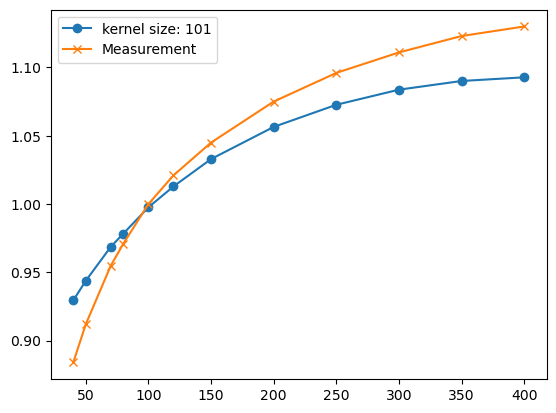

In [3]:
for index, result in enumerate(results):
    plt.plot(field_sizes, result, label=f"kernel size: {kernel_sizes[index]}", marker='o')
    plt.plot(field_sizes, of_measurements, label=f"Measurement", marker='x')
plt.legend()

In [ ]:
np.array(of_measurements) / np.array(results[0])

array([0.95114985, 0.96625787, 0.98583969, 0.9924529 , 1.0024157 ,
       1.008015  , 1.01169582, 1.01755076, 1.0217505 , 1.02516649,
       1.03018732, 1.0340562 ])

: 

In [4]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. THE DATA ---

dose_prediction_results = [0.92900451, 0.9439435 , 0.97013491, 0.97950569, 1.        ,
       1.01517666, 1.03624701, 1.06032325, 1.07728995, 1.08886611,
       1.09535178, 1.09811147]


# Treat original numbers as mm and convert to "cm-like" internal units (factor 10)
field_sizes = np.array(field_sizes) / 10.0
measured_points = np.array(of_measurements) / np.array(dose_prediction_results)

field_sizes = field_sizes[:8]
measured_points = measured_points[:8]


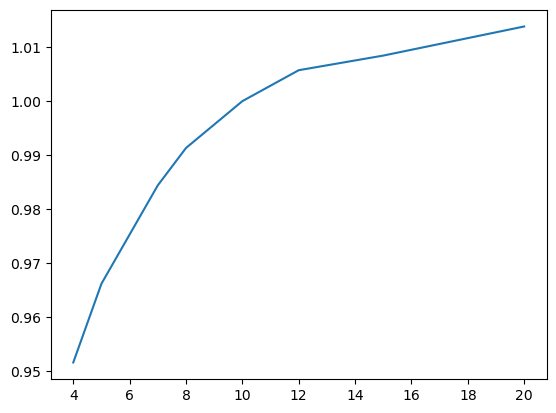

In [5]:
plt.plot(np.array(field_sizes), measured_points)
plt.show()

In [6]:
# Physical setup (same units as field_sizes, so "cm-like")
COLLIMATOR_DISTANCE_1 = 35.66  # from source
COLLIMATOR_DISTANCE_2 = 44.44  # from source
SOURCE_TO_ISO = 100.0          # source to isocenter

# Sigma ratio from geometry:
# For the same physical object, the closer collimator sees a larger apparent size.
# We enforce:  sigma2 = sigma1 * (distance_1 / distance_2)
SIGMA_RATIO = COLLIMATOR_DISTANCE_1 / COLLIMATOR_DISTANCE_2

print(f"Fixed sigma ratio: σ2/σ1 = {SIGMA_RATIO:.4f} (= {COLLIMATOR_DISTANCE_1}/{COLLIMATOR_DISTANCE_2})")
print("(Closer collimator sees larger apparent size ⇒ σ1 > σ2)")


Fixed sigma ratio: σ2/σ1 = 0.8024 (= 35.66/44.44)
(Closer collimator sees larger apparent size ⇒ σ1 > σ2)


In [7]:

# --- 2. THE PHYSICS MODEL ---
def sc_model(s, collimator_distance, w, sigma):
    """
    s: Field size at isocenter (same units as SOURCE_TO_ISO, e.g. 'cm-like')
    collimator_distance: Distance from source to collimator (same units)
    w: Weight of scatter source (relative to primary)
    sigma: Effective width parameter for the scatter source (same units as s)
    """
    # Project field size back to the collimator plane
    s_projected = s * (collimator_distance / SOURCE_TO_ISO)

    # 'View Factor' (Integral of Gaussian through square aperture, approximated)
    view_factor = (erf(s_projected / sigma))**2

    # Raw intensity (Primary + Weighted Scatter)
    raw_intensity = 1.0 + (w * view_factor)

    # Normalize to 10x10 field at isocenter (reference)
    ref_s_projected = 10.0 * (collimator_distance / SOURCE_TO_ISO)
    ref_view_factor = (erf(ref_s_projected / sigma))**2
    ref_intensity = 1.0 + (w * ref_view_factor)

    return raw_intensity / ref_intensity


def combined_model(field_sizes, w, d_sigma):
    """
    Combined model for both collimator directions.

    Parameters:
      w       : scatter weight (same for both directions)
      d_sigma : base sigma (effective source width scale, in same units as field size).
                We interpret:
                    sigma1 = d_sigma
                    sigma2 = d_sigma * SIGMA_RATIO
                so that sigma2/sigma1 is fixed by the collimator distance ratio.
    """

    sigma1 = d_sigma
    sigma2 = d_sigma * SIGMA_RATIO

    result_1 = sc_model(field_sizes, COLLIMATOR_DISTANCE_1, w, sigma1)
    result_2 = sc_model(field_sizes, COLLIMATOR_DISTANCE_2, w, sigma2)

    # Effective head scatter factor at isocenter (geometric mean)
    return np.sqrt(result_1 * result_2)



=== Simultaneous Optimization Results (1 size parameter, constrained σ ratio) ===
Base size parameter d_sigma: 3.2784 ± 0.1337 (same units as field size / sigma)
σ1 (collimator 1) = 3.2784
σ2 (collimator 2) = 2.6307  (σ2/σ1 = 0.8024)
Scatter weight w = 9.267 % ± 0.352 %

Interpreting field_sizes as mm/10, these correspond roughly to:
σ1 ≈ 32.78 mm
σ2 ≈ 26.31 mm


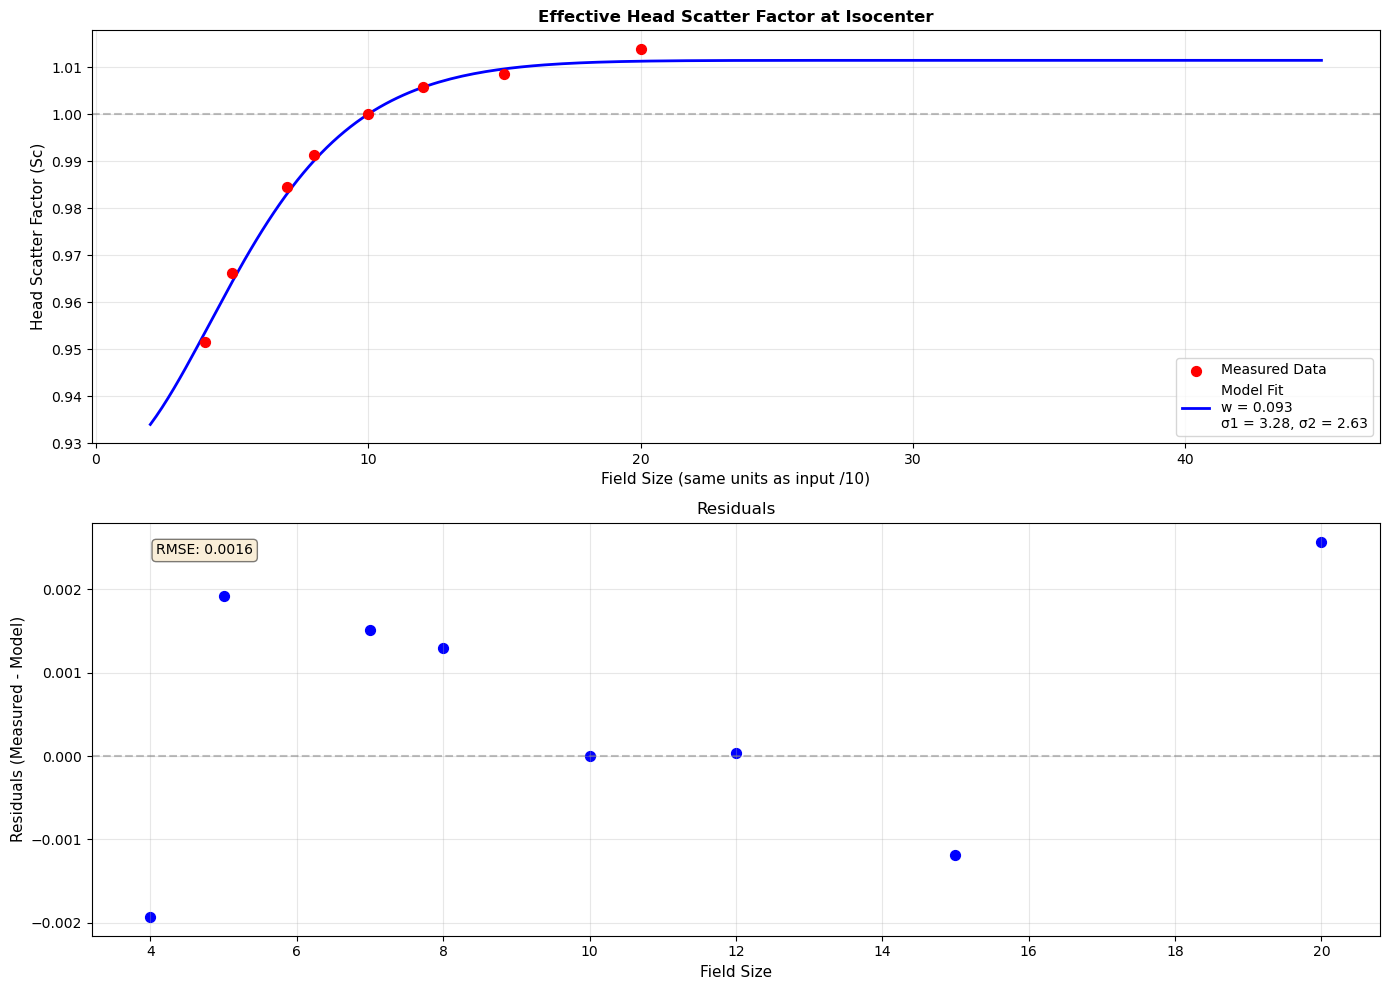

In [8]:


# --- 3. THE OPTIMIZATION ---

# Initial guesses: w ~ 0.08, d_sigma ~ few "cm-like" units
p0 = [0.05, 3.0]

# Bounds: w in [0, 0.2], d_sigma in [0, 50] (wide)
bounds = ([0.0, 0.0], [0.2, 50.0])

sigmas = np.ones_like(field_sizes)
# sigmas[4] = 0.00001
# sigmas[6] = 0.005
popt, pcov = curve_fit(
    combined_model,
    field_sizes,
    measured_points,
    p0=p0,
    sigma=sigmas,
    maxfev=10000
)

fitted_w, fitted_d_sigma = popt
# fitted_d_sigma = 3.0
perr = np.sqrt(np.diag(pcov))

# Derived sigmas for the two collimators
fitted_sigma1 = fitted_d_sigma
fitted_sigma2 = fitted_d_sigma * SIGMA_RATIO
# fitted_w = 0.05

print("\n=== Simultaneous Optimization Results (1 size parameter, constrained σ ratio) ===")
print(f"Base size parameter d_sigma: {fitted_d_sigma:.4f} ± {perr[1]:.4f} (same units as field size / sigma)")
print(f"σ1 (collimator 1) = {fitted_sigma1:.4f}")
print(f"σ2 (collimator 2) = {fitted_sigma2:.4f}  (σ2/σ1 = {fitted_sigma2/fitted_sigma1:.4f})")
print(f"Scatter weight w = {100*fitted_w:.3f} % ± {100*perr[0]:.3f} %")

# If you want to think in mm instead of "cm-like", multiply by 10:
print(f"\nInterpreting field_sizes as mm/10, these correspond roughly to:")
print(f"σ1 ≈ {10*fitted_sigma1:.2f} mm")
print(f"σ2 ≈ {10*fitted_sigma2:.2f} mm")

# --- 4. GENERATE SMOOTH CURVES & RESIDUALS ---

s_smooth = np.linspace(2, 45, 200)
sc_smooth_eff = combined_model(s_smooth, fitted_w, fitted_d_sigma)

# Model at measured points
model_at_points = combined_model(field_sizes, fitted_w, fitted_d_sigma)
residuals = measured_points - model_at_points

rmse = np.sqrt(np.mean(residuals**2))

# --- 5. PLOTTING ---

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Data + Fit
axes[0].scatter(field_sizes, measured_points, color='red', s=50,
                label='Measured Data', zorder=3)
axes[0].plot(
    s_smooth,
    sc_smooth_eff,
    color='blue',
    linewidth=2,
    label=(f'Model Fit\n'
           f'w = {fitted_w:.3f}\n'
           f'σ1 = {fitted_sigma1:.2f}, σ2 = {fitted_sigma2:.2f}')
)
axes[0].axhline(1.0, linestyle='--', color='gray', alpha=0.5)
axes[0].set_xlabel('Field Size (same units as input /10)', fontsize=11)
axes[0].set_ylabel('Head Scatter Factor (Sc)', fontsize=11)
axes[0].set_title('Effective Head Scatter Factor at Isocenter', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
axes[1].scatter(field_sizes, residuals, color='blue', s=50)
axes[1].axhline(0, linestyle='--', color='gray', alpha=0.5)
axes[1].set_xlabel('Field Size', fontsize=11)
axes[1].set_ylabel('Residuals (Measured - Model)', fontsize=11)
axes[1].set_title('Residuals', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].text(
    0.05, 0.95,
    f'RMSE: {rmse:.4f}',
    transform=axes[1].transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

plt.tight_layout()
plt.show()

In [9]:
print(f"Optimized sigmas are: [{str(np.round(fitted_sigma1, 3))}, {str(np.round(fitted_sigma2, 3))}]")
print(f"Optimized weights are: [{str(np.round(fitted_w, 3))}, {str(np.round(fitted_w, 3))}]")

Optimized sigmas are: [3.278, 2.631]
Optimized weights are: [0.093, 0.093]
